In [285]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [286]:
# 2.1 Collect the Data
df = pd.read_csv("../../../python_decal_fa25/course_assignments/homework9/noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [287]:
# 2.1.4
print(df.shape)
# 100 rows and 6 columns
print(df.head())
print(df.tail())
print(df.columns)
# Columns: 'x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


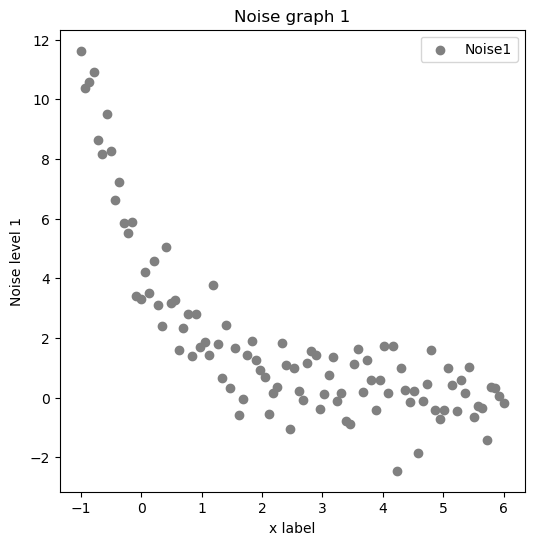

In [288]:
# 2.1.5
x = df['x']
y1 = df['y_noise_1']
plt.figure(figsize=(6,6))
plt.scatter(x, y1, c='gray', label= 'Noise1')
plt.xlabel('x label')
plt.ylabel('Noise level 1')
plt.legend()
plt.title('Noise graph 1')
plt.show()

In [289]:
# 2.2.1
# model is y = A * e ** (-k * x)
def model(x, A, k):
    return A * np.exp(-k * x)

In [290]:
# 2.2.2
p0 = [1,1]
popt, pcov = curve_fit(model, x, y1, p0=p0)

In [291]:
# 2.2.3
A_fit, k_fit = popt

In [292]:
# 2.2.4
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [293]:
# 2.2.5
residuals = y1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals ** 2)
dof = len(x) - len(popt)
chi2_reduced = f"{chi2 / dof:.2f}"  # Rounded reduced chi squared

chi2_reduced

'0.79'

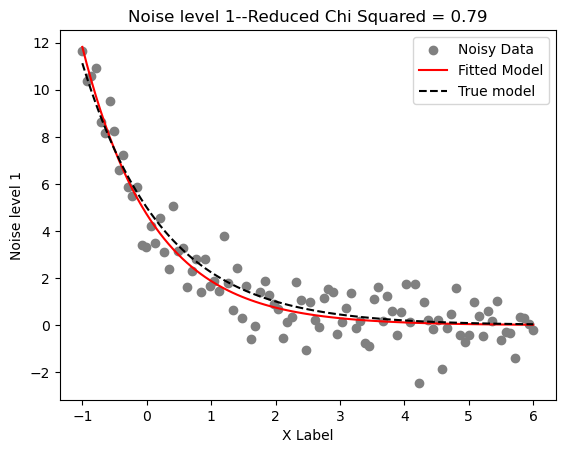

In [294]:
# 2.2.6
plt.figure()
plt.scatter(x, y1, c= "gray", label = 'Noisy Data')
plt.plot(x, model(x, 4.71, 0.92), c = "red", label = 'Fitted Model')
plt.plot(x, model(x, 5, 0.8), c = "black", linestyle = "--", label = 'True model')
plt.xlabel("X Label")
plt.ylabel("Noise level 1")
plt.legend()
plt.title("Noise level 1--Reduced Chi Squared = 0.79")
plt.show()

In [296]:
# 2.3 Compare Different Noise Levels
# 2.3.1 
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = f"{chi2 / dof:.2f}"
    return popt, chi2_reduced
print(fit_model(x, y1))
print(fit_model(x, y2))
print(fit_model(x, y3))
print(fit_model(x, y4))
print(fit_model(x, y5))

(array([4.71481388, 0.91830785]), '0.79')
(array([5.0638887 , 0.73039626]), '3.65')
(array([5.609396  , 0.87037195]), '10.41')
(array([5.73872674, 0.72596489]), '12.63')
(array([4.9434585 , 0.69501193]), '28.54')


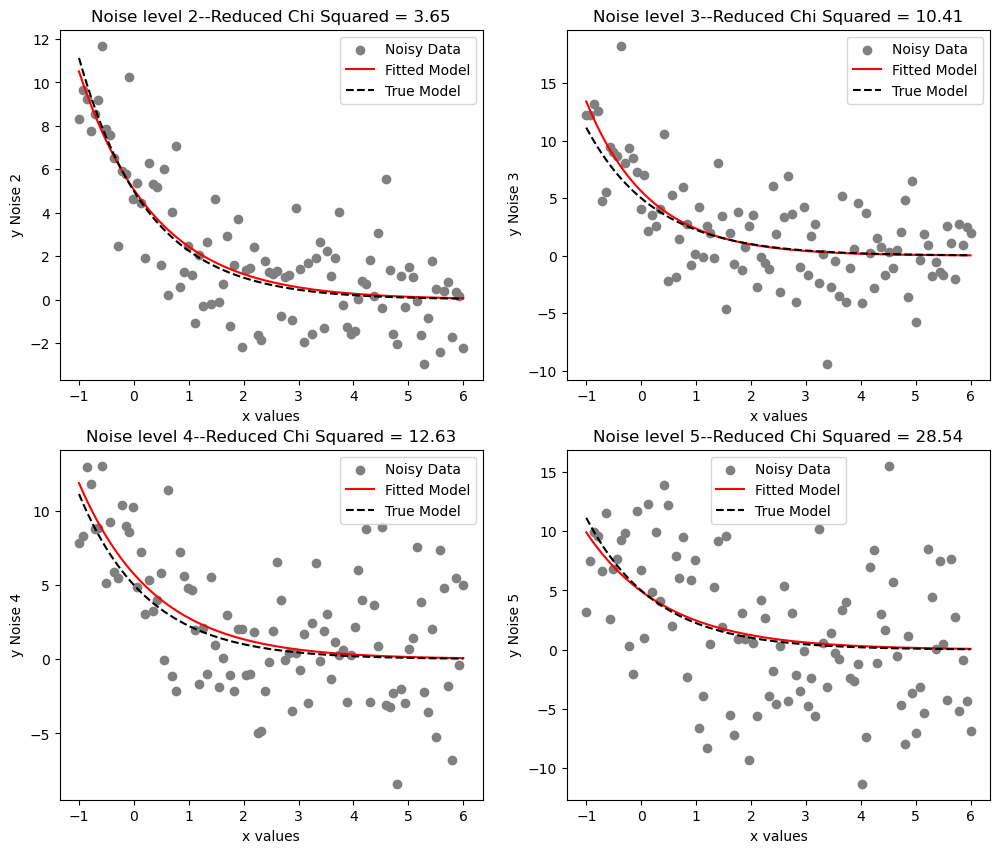

In [297]:
# 2.3.2-3
y2 = df['y_noise_2']
y3 = df['y_noise_3']
y4 = df['y_noise_4']
y5 = df['y_noise_5']
noise_levels = [y2, y3, y4, y5]

fit_model2 = fit_model(x, y2)
fit_model3 = fit_model(x, y3)
fit_model4 = fit_model(x, y4)
fit_model5 = fit_model(x, y5)
fit_models = [fit_model2, fit_model3, fit_model4, fit_model5]

titles = ["Noise level 2--Reduced Chi Squared = 3.65", "Noise level 3--Reduced Chi Squared = 10.41", "Noise level 4--Reduced Chi Squared = 12.63", "Noise level 5--Reduced Chi Squared = 28.54"]
xlabels = ["x values", "x values", "x values", "x values"]
ylabels = ["y Noise 2", " y Noise 3", "y Noise 4", "y Noise 5"]

fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, y_noise, title, xlabel, ylabel, in zip(axes.ravel(), noise_levels, titles, xlabels, ylabels):
    A = fit_model(x, y_noise)[0][0]
    k = fit_model(x, y_noise)[0][1]
    ax.scatter(x, y_noise, c = 'gray', label = 'Noisy Data')
    ax.plot(x, (A * np.exp(-k * x)), c = 'red', label = 'Fitted Model')
    ax.plot(x, model(x, 5, 0.8), c = 'black', linestyle = '--', label = 'True Model')  
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel) 

plt.show()

In [298]:
# 2.3.4
# 1. The dotted black and red line begin to match less accurately as more noise
# dissrupts the data. This is because more noise makes the fitted curve less acurate
# than the true model
# 2. The higher the noise level, the greater the reduced chi-squared. The more
# noise in your data, the less accurate the data. Greater chi-squared, the less 
# accurate data. Therefore greater greater noise --> greater chi-squared.

In [299]:
# 2.4 Save Your Results
# 2.4.1

# A fit
y1_A = fit_model(x, y1)[0][0]
y2_A = fit_model(x, y2)[0][0]
y3_A = fit_model(x, y3)[0][0]
y4_A = fit_model(x, y4)[0][0]
y5_A = fit_model(x, y5)[0][0]

# k fit
y1_k = fit_model(x, y1)[0][1]
y2_k = fit_model(x, y2)[0][1]
y3_k = fit_model(x, y3)[0][1]
y4_k = fit_model(x, y4)[0][1]
y5_k = fit_model(x, y5)[0][1]

# Chi_Squared
y1_chi = fit_model(x, y1)[1]
y2_chi = fit_model(x, y2)[1]
y3_chi = fit_model(x, y3)[1]
y4_chi = fit_model(x, y4)[1]
y5_chi = fit_model(x, y5)[1]

data = {
    'Noise Level': ['Noise Level 1', 'Noise Level 2', 'Noise Level 3', 'Noise Level 4', 'Noise Level 5'],
    'A Fit': [y1_A, y2_A, y3_A, y4_A, y5_A],
    'K fit': [y1_k, y2_k, y3_k, y4_k, y5_k],
    'Reduced Chi-Squared': [y1_chi, y2_chi, y3_chi, y4_chi, y5_chi],
}
    
df3 = pd.DataFrame(data)
df3

,Noise Level,A Fit,K fit,Reduced Chi-Squared
0,Noise Level 1,4.714814,0.918308,0.79
1,Noise Level 2,5.063889,0.730396,3.65
2,Noise Level 3,5.609396,0.870372,10.41
3,Noise Level 4,5.738727,0.725965,12.63
4,Noise Level 5,4.943458,0.695012,28.54


In [300]:
# 2.4.2
df3.to_csv("noisy_parameters.csv", index=False)